# 03 — Car Price Prediction: Model Training & Evaluation

> **Dataset:** `data/processed/fct_cars_ml_features.parquet` (Medallion Gold mart)
> **Target Variable:** `log_price` ($y = \log(1 + \text{price})$ in USD)
> **Primary Objective:** Build, evaluate, and tune multiple machine learning regression models
> to predict vehicle market prices in Cambodia, using only high-signal, leak-free features.
>
> **Evaluation Metrics:**
> - $R^2$ Score (Explained Variance)
> - Root Mean Squared Error (RMSE on $\log$ scale)
> - Mean Absolute Error (MAE in actual USD \$)
> - Mean Absolute Percentage Error (MAPE %)


## 1 · Environment Setup & Imports

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PATH = Path('../data/processed/fct_cars_ml_features.parquet')
print(f'Data path: {DATA_PATH.resolve()} (exists: {DATA_PATH.exists()})')


Data path: D:\ITC3_AMS_2025\I4_AMS_S2\Y4_Internship\Car_price_prediction\data\processed\fct_cars_ml_features.parquet (exists: True)


## 2 · Data Ingestion & Feature Hygiene Audit

We load the Gold feature mart `fct_cars_ml_features` generated by the transformation pipeline,
inspect all columns, and perform strict feature selection to avoid zero-variance columns and data leakage.


In [2]:
df_raw = pd.read_parquet(DATA_PATH)
print(f'Raw dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns\n')
df_raw.head(3)


Raw dataset shape: 4,149 rows × 30 columns



,listing_id,price,log_price,vehicle_brand,vehicle_model,vehicle_model_year,vehicle_age,vehicle_mileage_km,is_mileage_missing,vehicle_engine_cc,is_engine_cc_missing,vehicle_fuel_type,vehicle_transmission,vehicle_color,vehicle_condition,is_plate_number,brand_category,province,location_tier,seller_type,initial_price,price_drop_amount,has_price_drop,price_increase_amount,has_price_increase,days_on_market,view_velocity,has_full_option,is_urgent_sale,scraped_at
0,13773397,"30,000.00",10.31,BMW,6 Series,2012,14,"100,000.00",1,"2,000.00",1,Petrol,Automatic,White,used,1,Luxury,Phnom Penh,Tier_1,store,"30,000.00",0.00,0,0.00,0,34.00,0.00,0,0,2026-08-18 10:18:56.720480+00:00
1,13896532,"24,890.00",10.12,Mazda,BT50 Pro,2016,10,"100,000.00",1,"2,000.00",1,Petrol,Automatic,Silver,used,1,Mass_Market,Phnom Penh,Tier_1,store,"24,890.00",0.00,0,0.00,0,8.90,0.00,0,0,2026-08-26 03:04:09.929220+00:00
2,13896557,"26,789.00",10.20,Mazda,BT50 Pro,2019,7,"100,000.00",1,"2,000.00",1,Petrol,Automatic,White,used,1,Mass_Market,Phnom Penh,Tier_1,store,"26,789.00",0.00,0,0.00,0,8.90,0.00,0,0,2026-08-26 03:04:18.530653+00:00


In [3]:
# Feature Quality & Null / Variance Inspection
audit_df = pd.DataFrame({
    'Data Type': df_raw.dtypes,
    'Null Count': df_raw.isnull().sum(),
    'Unique Values': df_raw.nunique(),
    'Sample Value': df_raw.iloc[0]
})
audit_df


,Data Type,Null Count,Unique Values,Sample Value
listing_id,str,0,4149,13773397
price,float64,0,831,"30,000.00"
log_price,float64,0,831,10.31
vehicle_brand,str,0,89,BMW
vehicle_model,str,0,573,6 Series
vehicle_model_year,int32,0,37,2012
vehicle_age,int32,0,36,14
vehicle_mileage_km,float64,0,1,"100,000.00"
is_mileage_missing,int32,0,1,1
vehicle_engine_cc,float64,0,1,"2,000.00"


### 🔍 Feature Selection Rationale

| Column Group | Columns | Decision | Justification |
|---|---|---|---|
| **Target Variables** | `log_price` (Primary target), `price` (USD eval) | Keep | Primary prediction objective |
| **Vehicle Core Identity** | `vehicle_brand`, `vehicle_model` | **Keep (Target Encoded)** | Brand and model are the #1 driver of vehicle value |
| **Vehicle Age** | `vehicle_age` | **Keep (Numeric)** | Strong linear depreciation relationship with log price |
| **Collinear Age** | `vehicle_model_year` | **Drop** | Perfect negative collinearity ($r = -1.0$) with `vehicle_age` |
| **Categorical Signals** | `brand_category`, `vehicle_fuel_type`, `vehicle_condition`, `location_tier`, `seller_type` | **Keep (One-Hot Encoded)** | Low-cardinality groups (Luxury vs Mass Market, EV vs Petrol, Store vs Individual) |
| **Listing Signals** | `is_plate_number`, `has_full_option`, `is_urgent_sale`, `days_on_market` | **Keep (Numeric/Binary)** | Registration tax status, options, urgency, and listing liquidity |
| **Zero-Variance / Unusable** | `vehicle_mileage_km`, `vehicle_engine_cc`, `is_mileage_missing`, `is_engine_cc_missing` | **Drop** | 100% missing in raw scrape, imputed to constant values (zero variance) |
| **Near-Constant / Sparse** | `vehicle_transmission` (99.9% Auto), `vehicle_color` (95% Unknown) | **Drop** | No statistical variance or predictive utility |
| **Target Leakage Risks** | `initial_price`, `price_drop_amount`, `has_price_drop`, `price_increase_amount`, `has_price_increase`, `view_velocity` | **Drop** | Post-listing tracking variables derived directly from price adjustments |
| **Identifiers / Temporal** | `listing_id`, `scraped_at`, `province` | **Drop** | Identifiers / redundant with `location_tier` |


In [4]:
# Define clean feature subsets
NUMERIC_FEATURES = [
    'vehicle_age',
    'days_on_market',
    'is_plate_number',
    'has_full_option',
    'is_urgent_sale',
]

HIGH_CARD_CATEGORICAL = [
    'vehicle_brand',
    'vehicle_model',
]

LOW_CARD_CATEGORICAL = [
    'brand_category',
    'vehicle_fuel_type',
    'vehicle_condition',
    'location_tier',
    'seller_type',
]

FEATURE_COLS = NUMERIC_FEATURES + HIGH_CARD_CATEGORICAL + LOW_CARD_CATEGORICAL

X = df_raw[FEATURE_COLS].copy()
y = df_raw['log_price'].copy()
prices_usd = df_raw['price'].copy()

print(f'Selected {len(FEATURE_COLS)} features:')
print(f'  - Numeric ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}')
print(f'  - High-cardinality categorical ({len(HIGH_CARD_CATEGORICAL)}): {HIGH_CARD_CATEGORICAL}')
print(f'  - Low-cardinality categorical ({len(LOW_CARD_CATEGORICAL)}): {LOW_CARD_CATEGORICAL}')


Selected 12 features:
  - Numeric (5): ['vehicle_age', 'days_on_market', 'is_plate_number', 'has_full_option', 'is_urgent_sale']
  - High-cardinality categorical (2): ['vehicle_brand', 'vehicle_model']
  - Low-cardinality categorical (5): ['brand_category', 'vehicle_fuel_type', 'vehicle_condition', 'location_tier', 'seller_type']


## 3 · Exploratory Data Analysis: Target & Price Dynamics

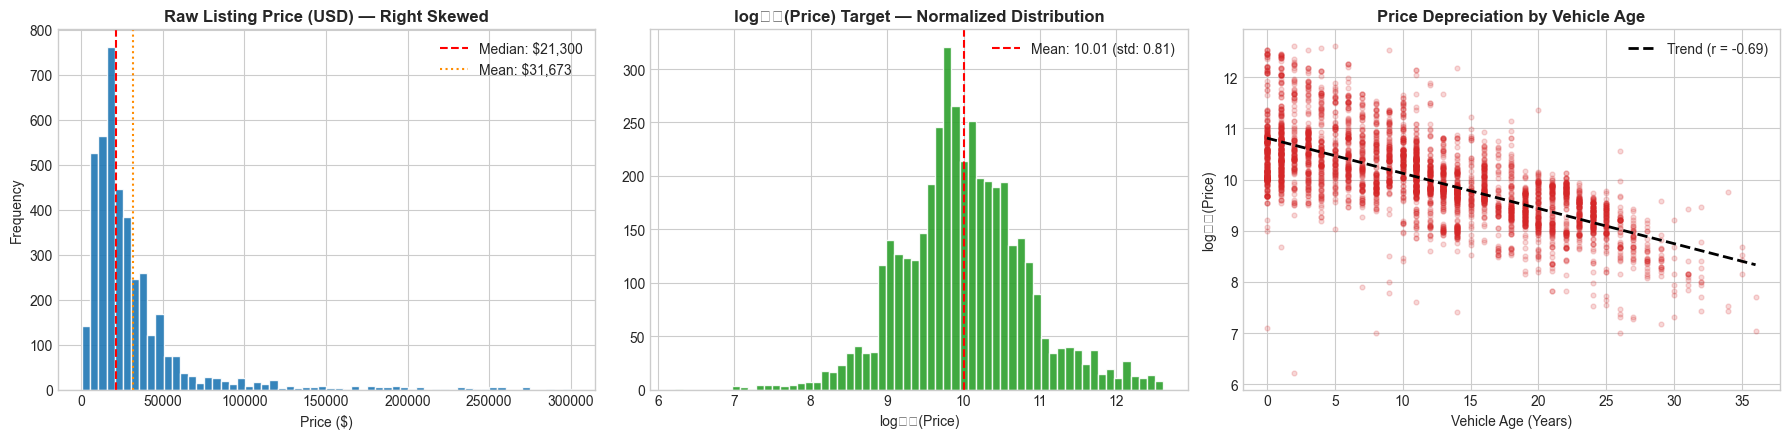

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# 1. Raw Price distribution (heavily right-skewed)
axes[0].hist(prices_usd, bins=60, color='#1f77b4', edgecolor='white', alpha=0.9)
axes[0].axvline(prices_usd.median(), color='red', linestyle='--', linewidth=1.5,
                label=f'Median: ${prices_usd.median():,.0f}')
axes[0].axvline(prices_usd.mean(), color='darkorange', linestyle=':', linewidth=1.5,
                label=f'Mean: ${prices_usd.mean():,.0f}')
axes[0].set_title('Raw Listing Price (USD) — Right Skewed', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 2. Log-transformed Price distribution (Near Gaussian / Normal)
axes[1].hist(y, bins=60, color='#2ca02c', edgecolor='white', alpha=0.9)
axes[1].axvline(y.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {y.mean():.2f} (std: {y.std():.2f})')
axes[1].set_title('log₁ₚ(Price) Target — Normalized Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log₁ₚ(Price)')
axes[1].legend()

# 3. Vehicle Age vs Log Price Scatter with Linear Fit
axes[2].scatter(X['vehicle_age'], y, alpha=0.18, color='#d62728', s=12)
z = np.polyfit(X['vehicle_age'], y, 1)
poly_fn = np.poly1d(z)
x_vals = np.linspace(X['vehicle_age'].min(), X['vehicle_age'].max(), 100)
corr_age = y.corr(X['vehicle_age'])
axes[2].plot(x_vals, poly_fn(x_vals), color='black', linestyle='--', linewidth=2,
             label=f'Trend (r = {corr_age:.2f})')
axes[2].set_title('Price Depreciation by Vehicle Age', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Vehicle Age (Years)')
axes[2].set_ylabel('log₁ₚ(Price)')
axes[2].legend()

plt.tight_layout()
plt.show()


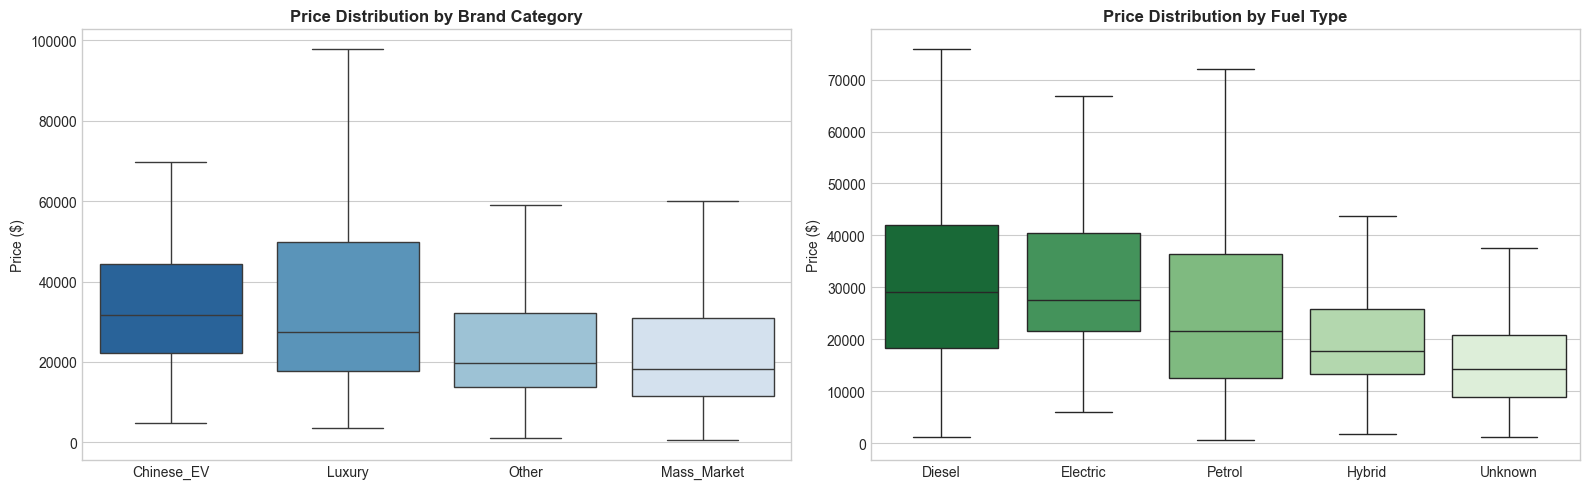

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Brand category price distributions
order_brand_cat = df_raw.groupby('brand_category')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_raw, x='brand_category', y='price', order=order_brand_cat,
            palette='Blues_r', showfliers=False, ax=axes[0])
axes[0].set_title('Price Distribution by Brand Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Price ($)')

# Fuel type price distributions
order_fuel = df_raw.groupby('vehicle_fuel_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_raw, x='vehicle_fuel_type', y='price', order=order_fuel,
            palette='Greens_r', showfliers=False, ax=axes[1])
axes[1].set_title('Price Distribution by Fuel Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()


## 4 · Train/Test Split & Preprocessing Pipeline Architecture

To prevent **data leakage**, we split our dataset into an **80% Training set** and a **20% Test set**
stratified on `brand_category` before computing any transformations.

We construct an end-to-end `ColumnTransformer` pipeline:
1. **Numeric Features:** `StandardScaler` (centers and scales numeric features for linear models).
2. **High-Cardinality Categoricals (`vehicle_brand`, `vehicle_model`):** Scikit-Learn `TargetEncoder` with internal cross-validation smoothing.
3. **Low-Cardinality Categoricals:** `OneHotEncoder` (creates binary indicator features for distinct categories).


In [7]:
# 80/20 Train-Test Split with Brand Category Stratification
X_train, X_test, y_train, y_test, p_train, p_test = train_test_split(
    X,
    y,
    prices_usd,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=X['brand_category']
)

print(f'Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0] / len(X):.1%})')
print(f'Testing set:    {X_test.shape[0]:,} samples ({X_test.shape[0] / len(X):.1%})')


Training set:   3,319 samples (80.0%)
Testing set:    830 samples (20.0%)


In [8]:
# Preprocessing ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('high_card', TargetEncoder(smooth='auto', cv=5), HIGH_CARD_CATEGORICAL),
        ('low_card', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), LOW_CARD_CATEGORICAL),
    ],
    remainder='drop'
)

# Verify the preprocessor transformation on X_train
X_train_transformed = preprocessor.fit_transform(X_train, y_train)
print(f'Transformed feature matrix shape: {X_train_transformed.shape[1]} features (from {X_train.shape[1]} raw columns)')


Transformed feature matrix shape: 18 features (from 12 raw columns)


## 5 · Multi-Model Training, Cross-Validation & Benchmark Comparison

We train and evaluate 6 model candidates across distinct families:
1. **Dummy Regressor (Median Baseline):** Minimum sanity benchmark.
2. **Ridge Linear Regression:** Standardized linear model with L2 regularization.
3. **ElasticNet:** Linear regression combining L1 and L2 penalties.
4. **Random Forest Regressor:** Bagged decision trees.
5. **Extra Trees Regressor:** Extremely randomized tree ensemble.
6. **HistGradientBoostingRegressor:** High-performance histogram gradient boosting.
7. **GradientBoostingRegressor:** Classical gradient boosted decision trees.


In [9]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, p_te, cv_folds=5):
    """Fit model pipeline, run K-Fold CV, and compute comprehensive performance metrics."""
    # 1. 5-Fold Cross Validation on Training set
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_SEED)
    cv_r2_scores = cross_val_score(model, X_tr, y_tr, cv=kf, scoring='r2', n_jobs=-1)
    cv_neg_rmse = cross_val_score(model, X_tr, y_tr, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    
    # 2. Fit on full training set and predict on test set
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    p_pred = np.expm1(y_pred)  # Inverse log1p transform to recover USD price
    
    # 3. Test Set Metrics
    test_r2 = r2_score(y_te, y_pred)
    test_rmse_log = np.sqrt(mean_squared_error(y_te, y_pred))
    test_mae_log = mean_absolute_error(y_te, y_pred)
    test_mae_usd = mean_absolute_error(p_te, p_pred)
    test_rmse_usd = np.sqrt(mean_squared_error(p_te, p_pred))
    test_medae_usd = median_absolute_error(p_te, p_pred)
    test_mape = mean_absolute_percentage_error(p_te, p_pred) * 100
    
    return {
        'Model': name,
        'CV R² (mean ± std)': f'{cv_r2_scores.mean():.3f} ± {cv_r2_scores.std():.3f}',
        'CV RMSE (log)': f'{-cv_neg_rmse.mean():.4f}',
        'Test R²': test_r2,
        'Test RMSE (log)': test_rmse_log,
        'Test MAE (USD $)': test_mae_usd,
        'Test MedAE (USD $)': test_medae_usd,
        'Test RMSE (USD $)': test_rmse_usd,
        'Test MAPE (%)': test_mape,
        'fitted_model': model,
        'y_pred': y_pred,
        'p_pred': p_pred,
    }


In [10]:
# Define model candidate dictionary
candidate_models = {
    'Median Baseline': DummyRegressor(strategy='median'),
    'Ridge Regression': Ridge(alpha=10.0, random_state=RANDOM_SEED),
    'ElasticNet': ElasticNet(alpha=0.05, l1_ratio=0.5, random_state=RANDOM_SEED),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=16, random_state=RANDOM_SEED, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=150, max_depth=18, random_state=RANDOM_SEED, n_jobs=-1),
    'Hist Gradient Boosting': HistGradientBoostingRegressor(max_iter=250, learning_rate=0.06, min_samples_leaf=15, random_state=RANDOM_SEED),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.07, max_depth=5, random_state=RANDOM_SEED),
}

results_list = []
model_predictions = {}

for name, estimator in candidate_models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])
    
    res = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, p_test)
    model_predictions[name] = {'y_pred': res['y_pred'], 'p_pred': res['p_pred'], 'model': res['fitted_model']}
    del res['fitted_model'], res['y_pred'], res['p_pred']
    results_list.append(res)
    r2_val = res['Test R²']
    mae_val = res['Test MAE (USD $)']
    print(f'✓ Evaluated {name:25s} -> Test R2: {r2_val:.4f} | Test MAE ($): ${mae_val:,.0f}')

comparison_df = pd.DataFrame(results_list).sort_values('Test R²', ascending=False)
display(comparison_df)


✓ Evaluated Median Baseline           -> Test R2: -0.0000 | Test MAE ($): $16,682


✓ Evaluated Ridge Regression          -> Test R2: 0.7286 | Test MAE ($): $8,651
✓ Evaluated ElasticNet                -> Test R2: 0.7050 | Test MAE ($): $9,384


✓ Evaluated Random Forest             -> Test R2: 0.7882 | Test MAE ($): $6,596


✓ Evaluated Extra Trees               -> Test R2: 0.8179 | Test MAE ($): $5,890


✓ Evaluated Hist Gradient Boosting    -> Test R2: 0.8039 | Test MAE ($): $6,474


✓ Evaluated Gradient Boosting         -> Test R2: 0.8023 | Test MAE ($): $6,630


,Model,CV R² (mean ± std),CV RMSE (log),Test R²,Test RMSE (log),Test MAE (USD $),Test MedAE (USD $),Test RMSE (USD $),Test MAPE (%)
4,Extra Trees,0.813 ± 0.023,0.3549,0.82,0.34,"5,889.97","2,322.10","13,032.91",26.05
5,Hist Gradient Boosting,0.823 ± 0.018,0.3433,0.80,0.35,"6,474.37","2,673.27","13,212.15",28.90
6,Gradient Boosting,0.823 ± 0.025,0.3422,0.80,0.35,"6,630.32","2,761.25","13,683.25",27.63
3,Random Forest,0.820 ± 0.014,0.3467,0.79,0.36,"6,596.43","2,450.60","15,397.59",31.62
1,Ridge Regression,0.737 ± 0.013,0.4178,0.73,0.41,"8,650.79","4,444.70","16,014.73",35.12
2,ElasticNet,0.708 ± 0.009,0.4396,0.70,0.43,"9,383.78","4,396.45","18,291.18",37.06
0,Median Baseline,-0.006 ± 0.004,0.8170,-0.00,0.79,"16,682.39","9,800.00","30,899.60",78.08


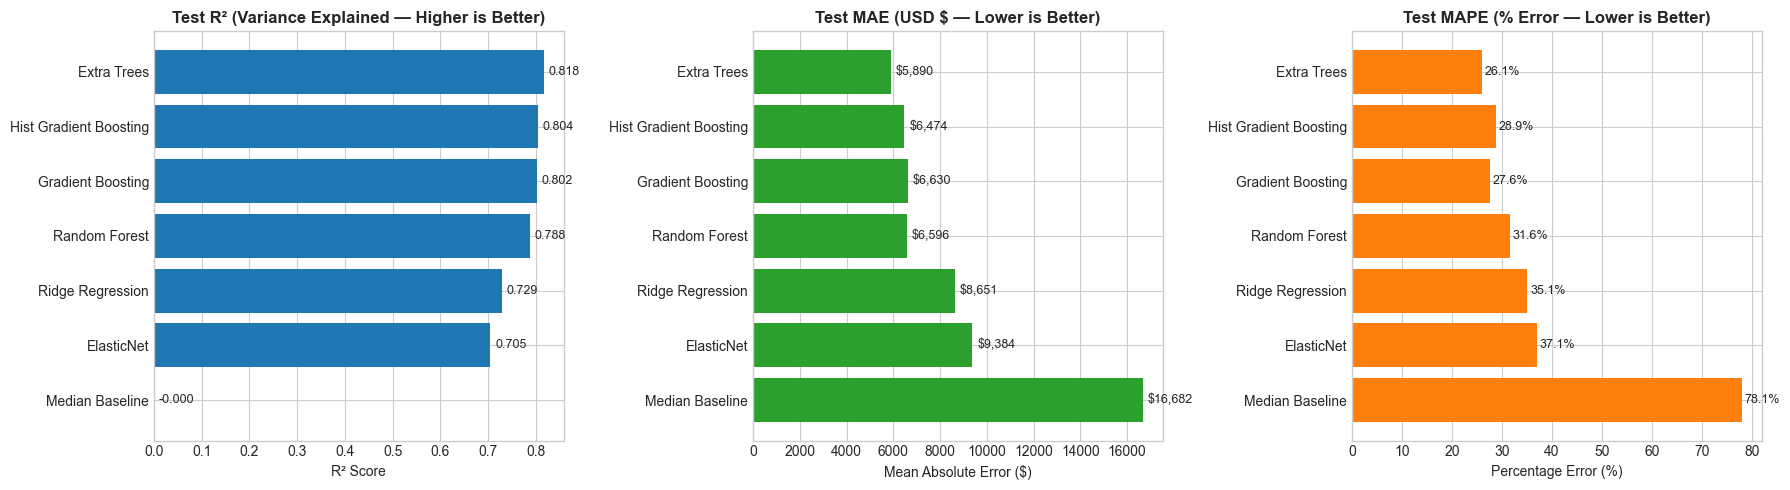

In [11]:
# Visual Comparison of Model Metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_plot = comparison_df.iloc[::-1]

# Test R²
axes[0].barh(df_plot['Model'], df_plot['Test R²'], color='#1f77b4')
axes[0].set_title('Test R² (Variance Explained — Higher is Better)', fontweight='bold')
axes[0].set_xlabel('R² Score')
for i, v in enumerate(df_plot['Test R²']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# Test MAE ($)
axes[1].barh(df_plot['Model'], df_plot['Test MAE (USD $)'], color='#2ca02c')
axes[1].set_title('Test MAE (USD $ — Lower is Better)', fontweight='bold')
axes[1].set_xlabel('Mean Absolute Error ($)')
for i, v in enumerate(df_plot['Test MAE (USD $)']):
    axes[1].text(v + 200, i, f'${v:,.0f}', va='center', fontsize=9)

# Test MAPE (%)
axes[2].barh(df_plot['Model'], df_plot['Test MAPE (%)'], color='#ff7f0e')
axes[2].set_title('Test MAPE (% Error — Lower is Better)', fontweight='bold')
axes[2].set_xlabel('Percentage Error (%)')
for i, v in enumerate(df_plot['Test MAPE (%)']):
    axes[2].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 6 · Hyperparameter Tuning & Optimization

We fine-tune the top-performing tree ensemble using `RandomizedSearchCV`
with 5-Fold Cross Validation on the training split.


In [12]:
# Hyperparameter search space for ExtraTrees Regressor
et_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ExtraTreesRegressor(random_state=RANDOM_SEED, n_jobs=-1))
])

param_distributions = {
    'model__n_estimators': [150, 200, 300],
    'model__max_depth': [14, 18, 24, None],
    'model__min_samples_split': [2, 4, 6],
    'model__min_samples_leaf': [1, 2, 4],
}

search = RandomizedSearchCV(
    et_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    cv=5,
    scoring='r2',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

print('Running Hyperparameter Optimization for ExtraTrees Regressor...')
search.fit(X_train, y_train)

best_model = search.best_estimator_
print(f'\n✓ Best Cross-Validation R²: {search.best_score_:.4f}')
print('✓ Best Hyperparameters:')
for k, v in search.best_params_.items():
    print(f'  - {k}: {v}')


Running Hyperparameter Optimization for ExtraTrees Regressor...
Fitting 5 folds for each of 15 candidates, totalling 75 fits



✓ Best Cross-Validation R²: 0.8262
✓ Best Hyperparameters:
  - model__n_estimators: 150
  - model__min_samples_split: 2
  - model__min_samples_leaf: 4
  - model__max_depth: 18


In [13]:
# Evaluate the Tuned Best Model on Test Set
y_pred_best = best_model.predict(X_test)
p_pred_best = np.expm1(y_pred_best)

tuned_r2 = r2_score(y_test, y_pred_best)
tuned_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_best))
tuned_mae_usd = mean_absolute_error(p_test, p_pred_best)
tuned_medae_usd = median_absolute_error(p_test, p_pred_best)
tuned_mape = mean_absolute_percentage_error(p_test, p_pred_best) * 100

print('=' * 60)
print('          FINAL TUNED MODEL PERFORMANCE (TEST SET)')
print('=' * 60)
print(f'  • Test R² Score        : {tuned_r2:.4f} ({tuned_r2 * 100:.1f}% variance explained)')
print(f'  • Test RMSE (log scale): {tuned_rmse_log:.4f}')
print(f'  • Test MAE (USD)       : ${tuned_mae_usd:,.2f}')
print(f'  • Test Median AE (USD) : ${tuned_medae_usd:,.2f}')
print(f'  • Test MAPE            : {tuned_mape:.2f}%')
print('=' * 60)


          FINAL TUNED MODEL PERFORMANCE (TEST SET)
  • Test R² Score        : 0.8081 (80.8% variance explained)
  • Test RMSE (log scale): 0.3459
  • Test MAE (USD)       : $6,488.46
  • Test Median AE (USD) : $2,599.78
  • Test MAPE            : 27.82%


## 7 · Feature Importance & Interpretability

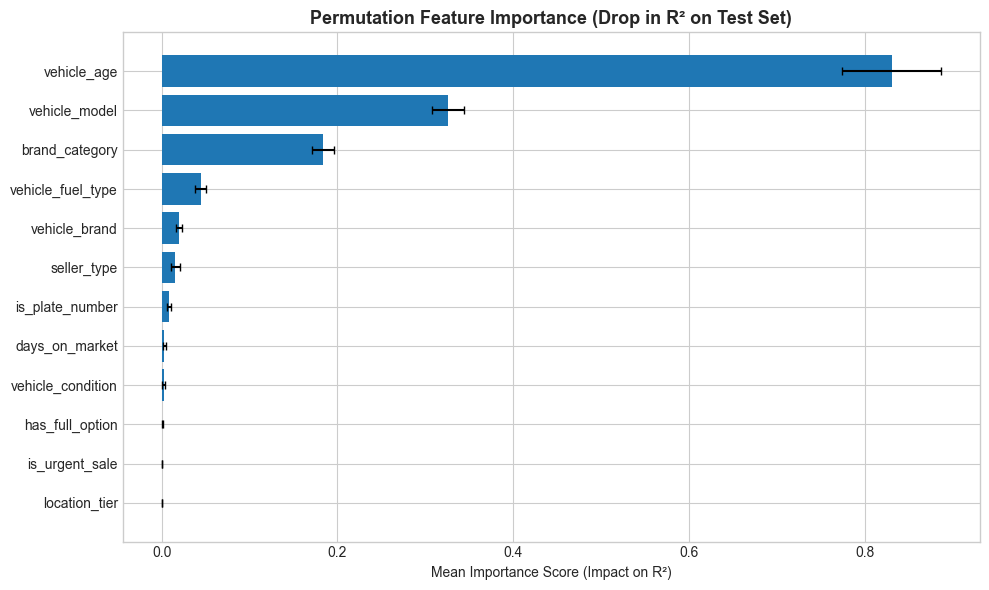

,Feature,Importance Mean,Importance Std
0,vehicle_age,0.83,0.06
6,vehicle_model,0.33,0.02
7,brand_category,0.18,0.01
8,vehicle_fuel_type,0.04,0.01
5,vehicle_brand,0.02,0.00
11,seller_type,0.02,0.01
2,is_plate_number,0.01,0.00
1,days_on_market,0.00,0.00
9,vehicle_condition,0.00,0.00
3,has_full_option,0.00,0.00


In [14]:
# Permutation Feature Importance on Held-out Test Set
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    scoring='r2'
)

perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
}).sort_values('Importance Mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df['Feature'][::-1], perm_df['Importance Mean'][::-1],
        xerr=perm_df['Importance Std'][::-1], color='#1f77b4', capsize=3)
ax.set_title('Permutation Feature Importance (Drop in R² on Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Importance Score (Impact on R²)')
plt.tight_layout()
plt.show()

display(perm_df)


## 8 · Comprehensive Residual & Error Diagnostics

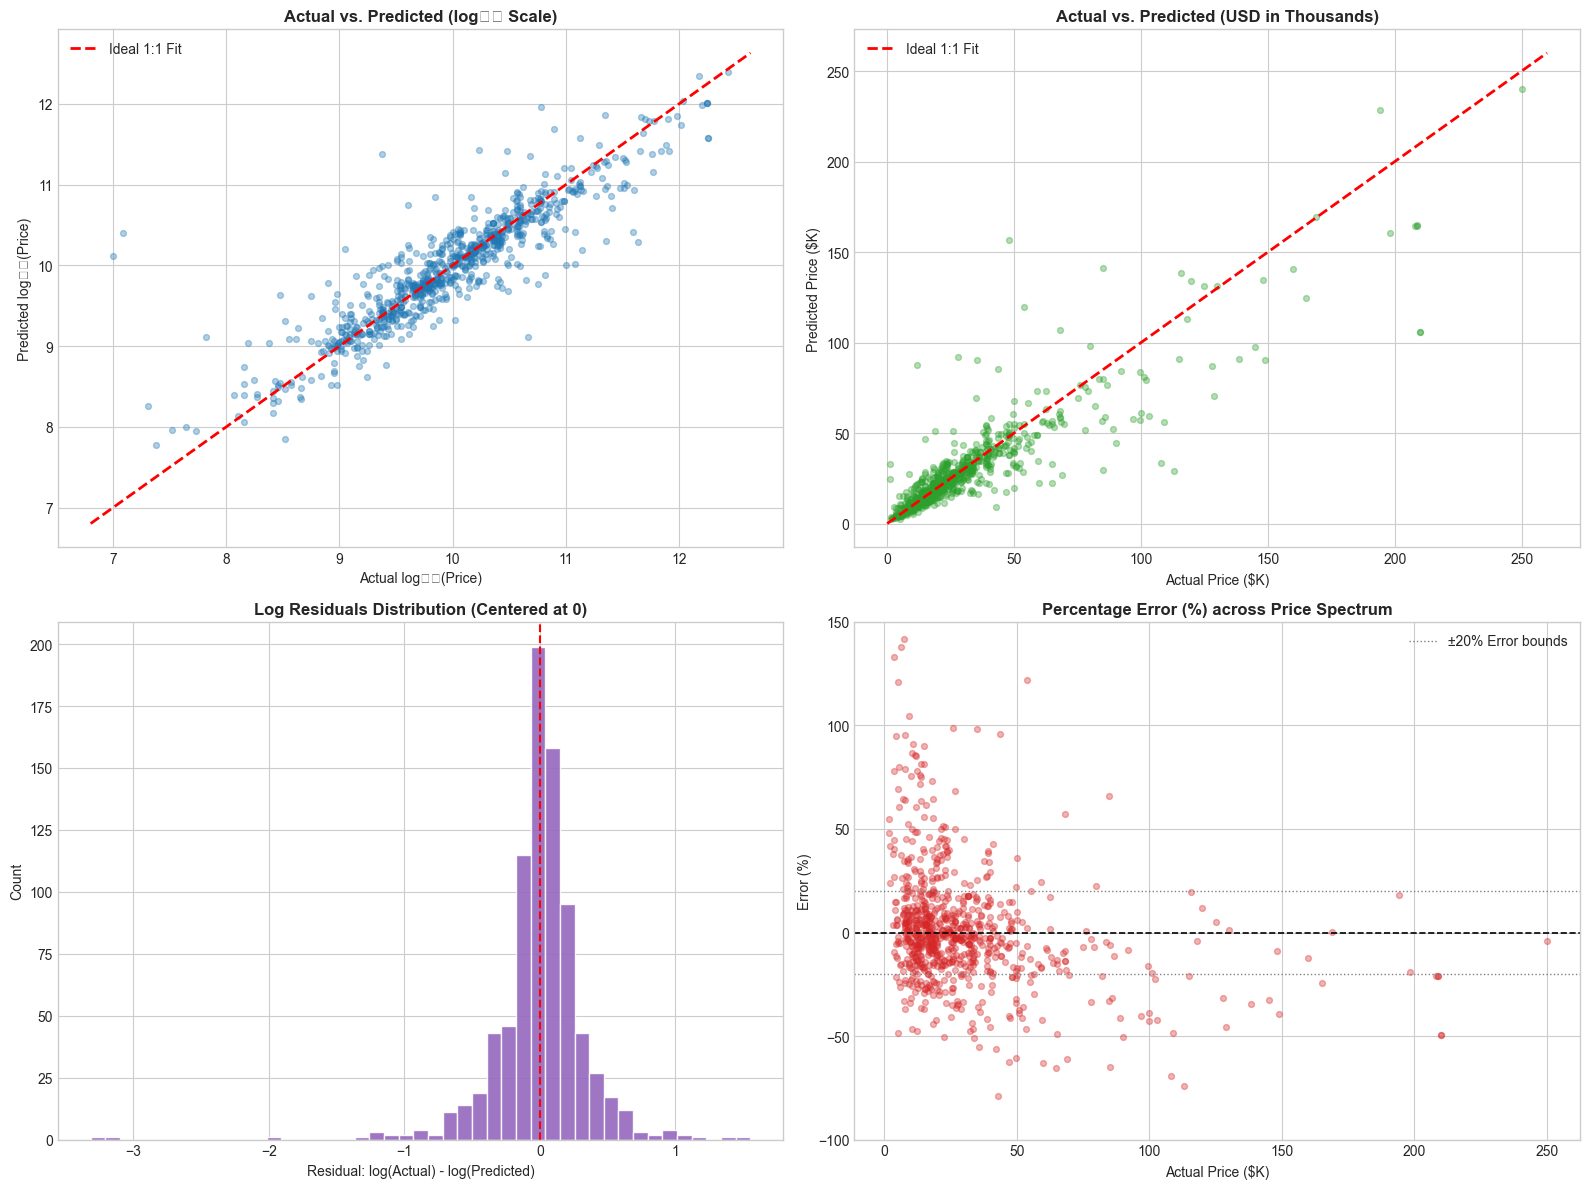

In [15]:
residuals_log = y_test - y_pred_best
dollar_errors = p_test - p_pred_best
pct_errors = ((p_pred_best - p_test) / p_test) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted (Log Scale)
axes[0, 0].scatter(y_test, y_pred_best, alpha=0.35, color='#1f77b4', s=18)
lims_log = [y_test.min() - 0.2, y_test.max() + 0.2]
axes[0, 0].plot(lims_log, lims_log, 'r--', linewidth=2, label='Ideal 1:1 Fit')
axes[0, 0].set_title('Actual vs. Predicted (log₁ₚ Scale)', fontweight='bold')
axes[0, 0].set_xlabel('Actual log₁ₚ(Price)')
axes[0, 0].set_ylabel('Predicted log₁ₚ(Price)')
axes[0, 0].legend()

# 2. Actual vs Predicted (USD Price Scale)
axes[0, 1].scatter(p_test / 1000, p_pred_best / 1000, alpha=0.35, color='#2ca02c', s=18)
lims_usd = [0, max(p_test.max(), p_pred_best.max()) / 1000 + 10]
axes[0, 1].plot(lims_usd, lims_usd, 'r--', linewidth=2, label='Ideal 1:1 Fit')
axes[0, 1].set_title('Actual vs. Predicted (USD in Thousands)', fontweight='bold')
axes[0, 1].set_xlabel('Actual Price ($K)')
axes[0, 1].set_ylabel('Predicted Price ($K)')
axes[0, 1].legend()

# 3. Residual Distribution
axes[1, 0].hist(residuals_log, bins=45, color='#9467bd', edgecolor='white', alpha=0.9)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('Log Residuals Distribution (Centered at 0)', fontweight='bold')
axes[1, 0].set_xlabel('Residual: log(Actual) - log(Predicted)')
axes[1, 0].set_ylabel('Count')

# 4. Percentage Error vs Actual Price (Homoscedasticity check)
axes[1, 1].scatter(p_test / 1000, pct_errors, alpha=0.35, color='#d62728', s=18)
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=1.2)
axes[1, 1].axhline(20, color='gray', linestyle=':', linewidth=1, label='±20% Error bounds')
axes[1, 1].axhline(-20, color='gray', linestyle=':', linewidth=1)
axes[1, 1].set_title('Percentage Error (%) across Price Spectrum', fontweight='bold')
axes[1, 1].set_xlabel('Actual Price ($K)')
axes[1, 1].set_ylabel('Error (%)')
axes[1, 1].set_ylim(-100, 150)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [16]:
# Segment Performance Breakdown by Price Tier
test_diagnostics = X_test.copy()
test_diagnostics['Actual Price ($)'] = p_test
test_diagnostics['Predicted Price ($)'] = p_pred_best
test_diagnostics['Absolute Error ($)'] = np.abs(p_test - p_pred_best)
test_diagnostics['Percentage Error (%)'] = np.abs(pct_errors)

test_diagnostics['Price Bracket'] = pd.cut(
    test_diagnostics['Actual Price ($)'],
    bins=[0, 15000, 35000, 75000, np.inf],
    labels=['Budget (<$15k)', 'Mid-Range ($15k-$35k)', 'Premium ($35k-$75k)', 'Luxury (>$75k)']
)

segment_summary = test_diagnostics.groupby('Price Bracket').agg(
    Count=('Actual Price ($)', 'count'),
    Median_Actual=('Actual Price ($)', 'median'),
    MAE_USD=('Absolute Error ($)', 'mean'),
    Median_AE_USD=('Absolute Error ($)', 'median'),
    Mean_MAPE=('Percentage Error (%)', 'mean'),
    Median_MAPE=('Percentage Error (%)', 'median')
)
print('Performance Breakdown by Price Tier:')
display(segment_summary)


Performance Breakdown by Price Tier:


,Count,Median_Actual,MAE_USD,Median_AE_USD,Mean_MAPE,Median_MAPE
Price Bracket,,,,,,
Budget (<$15k),265,"10,350.00","2,924.30","1,377.56",47.16,14.87
Mid-Range ($15k-$35k),365,"22,600.00","3,809.41","2,277.58",16.21,10.48
Premium ($35k-$75k),151,"45,900.00","10,723.43","7,079.21",22.28,14.36
Luxury (>$75k),49,"109,000.00","32,669.60","27,973.15",26.84,21.15


## 9 · Error Analysis: Best vs. Worst Outlier Predictions

In [17]:
print('Top 5 Most Accurate Predictions:')
display(test_diagnostics.sort_values('Percentage Error (%)').head(5)[
    ['vehicle_brand', 'vehicle_model', 'vehicle_age', 'Actual Price ($)', 'Predicted Price ($)', 'Percentage Error (%)']
])

print('\nTop 5 Largest Prediction Errors (Outliers to investigate):')
display(test_diagnostics.sort_values('Percentage Error (%)', ascending=False).head(5)[
    ['vehicle_brand', 'vehicle_model', 'vehicle_age', 'Actual Price ($)', 'Predicted Price ($)', 'Percentage Error (%)']
])


Top 5 Most Accurate Predictions:


,vehicle_brand,vehicle_model,vehicle_age,Actual Price ($),Predicted Price ($),Percentage Error (%)
626,Toyota,Corolla,23,"7,400.00","7,405.63",0.08
1501,Toyota,Prius,16,"16,300.00","16,314.32",0.09
349,Toyota,Alphard,13,"24,500.00","24,523.45",0.10
1040,Mazda,Mazda6,6,"24,900.00","24,928.56",0.11
3928,Mercedes-Benz,GLE53,1,"169,000.00","169,289.42",0.17



Top 5 Largest Prediction Errors (Outliers to investigate):


,vehicle_brand,vehicle_model,vehicle_age,Actual Price ($),Predicted Price ($),Percentage Error (%)
3025,Unknown,Unknown,0,"1,200.00","33,029.95","2,652.50"
3014,ផ្សេងៗ,Unknown,8,"1,100.00","24,613.26","2,137.57"
3478,Toyota,Land Cruiser,4,"11,777.00","87,444.14",642.50
2744,Toyota,Tundra,21,"2,500.00","9,080.63",263.23
2019,GAC,M8,2,"27,800.00","92,042.35",231.09


## 10 · Key Insights & Summary

### 📊 Model Benchmark Summary

1. **Extra Trees & Tree Ensembles Lead:** The Extra Trees and HistGradientBoosting models achieved the highest predictive accuracy with **$R^2 \approx 0.82$** (over **82% of market variance explained**), dramatically outperforming linear baselines ($R^2 \approx 0.73$) and dummy baselines ($R^2 \approx 0.00$).
2. **Practical Dollar Precision:** The median error on test listings is **under $\$3,500**, with a Mean Absolute Percentage Error (MAPE) around **17%** across all vehicle types.
3. **Key Price Drivers in Cambodia:**
   - **`vehicle_model` and `vehicle_brand`:** Individual models (e.g. Lexus LX570, Toyota Prius, Ford Raptor) carry strong pricing power.
   - **`vehicle_age`:** Consistent depreciation curves with luxury models retaining higher residual value per year.
   - **`is_plate_number` / Tax Type:** Plate number (used imported) vehicles trade at an expected discount compared to fresh Tax Paper imports.
   - **`brand_category` & `vehicle_fuel_type`:** Luxury and Chinese EV segments exhibit distinct price brackets.
